In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import marching_cubes
from plotting import plot3d

# Directory structure

```
data_root/
├── model_0000/
│ ├── image3d.bin
│ ├── vp3d.bin
│ ├── rgt3d.bin
├── model_0001/
│ ├── image3d.bin
│ ├── vp3d.bin
│ ├── rgt3d.bin
```

Each binary files are saved with `float32` datatype (Little endian) with `96 x 96 x 96` (X, Y, Z)

In [4]:
def read_models(data_root, model_folders, index):
    image_file = os.path.join(data_root, model_folders[index], "image3d.bin") # seismic image
    vp_file = os.path.join(data_root, model_folders[index], "vp3d.bin") # velocity model
    rgt_file = os.path.join(data_root, model_folders[index], "rgt3d.bin") # relative geologic time
    fault_file = os.path.join(data_root, model_folders[index], "fault3d.bin") # fault model

    shape = (96, 96, 96)

    image = np.memmap(
        image_file,
        dtype=np.float32,
        mode='r',
        shape=shape
    )

    vp = np.memmap(
        vp_file,
        dtype=np.float32,
        mode='r',
        shape=shape
    )

    rgt = np.memmap(
        rgt_file,
        dtype=np.float32,
        mode='r',
        shape=shape
    )

    fault = np.memmap(
        fault_file,
        dtype=np.float32,
        mode='r',
        shape=shape
    )

    salt = rgt == 0
    salt_mask = salt.astype(np.float32)

    return image, vp, rgt, fault, salt_mask

In [56]:
def plot_all_models(data_root, model_folders, index, suptitle=None, save_path=None):
    image, vp, rgt, fault, salt = read_models(data_root, model_folders, index)

    fig, ax = plt.subplots(
        2, 3, 
        figsize=(10, 10), 
        subplot_kw={'projection': '3d'},
        constrained_layout=True
    )
    axes = ax.ravel()

    data_list = [image, vp, rgt, fault, salt]

    titles = ["Seismic image", "Velocity model", "Relative geologic time", "Fault Index", "Salt Mask"]

    cmaps = ['gray', 'jet', 'viridis', 'jet', 'Reds']

    for ax, data, title, cmap_name in zip(axes, data_list, titles, cmaps):
        ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
        
        plt.sca(ax)
        plot3d(
            data.T,
            cmap=cmap_name,
            frames=[45, 30, 60],
            ifnewfig=False,  
            showf=False,     
            close=False,     
            ifinside=False,
        )

    if suptitle is not None:
        plt.suptitle(suptitle, fontsize=20, fontweight='bold', y=1.05)

    axes[-1].axis('off')

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


## Layered model 

In [13]:
# data_root = "../allmodels/"
data_root = "/home/mssujith/lanl/NeurIPS26/output3d/"

# Get all model folders
model_folders = [f'model_{i:04d}' for i in range(0, 10000)]

shape = (96, 96, 96)

In [35]:
image, vp, rgt, fault, salt = read_models(data_root, model_folders, 6526)

print("#"*100)
print(f'Shape of the model: {vp.shape}')
print(f'Minimum velocity: {vp.min():.2f} m/s')
print(f'Maximum velocity: {vp.max():.2f} m/s')
print("#"*100)

####################################################################################################
Shape of the model: (96, 96, 96)
Minimum velocity: 1958.01 m/s
Maximum velocity: 3720.20 m/s
####################################################################################################


## Plot the models

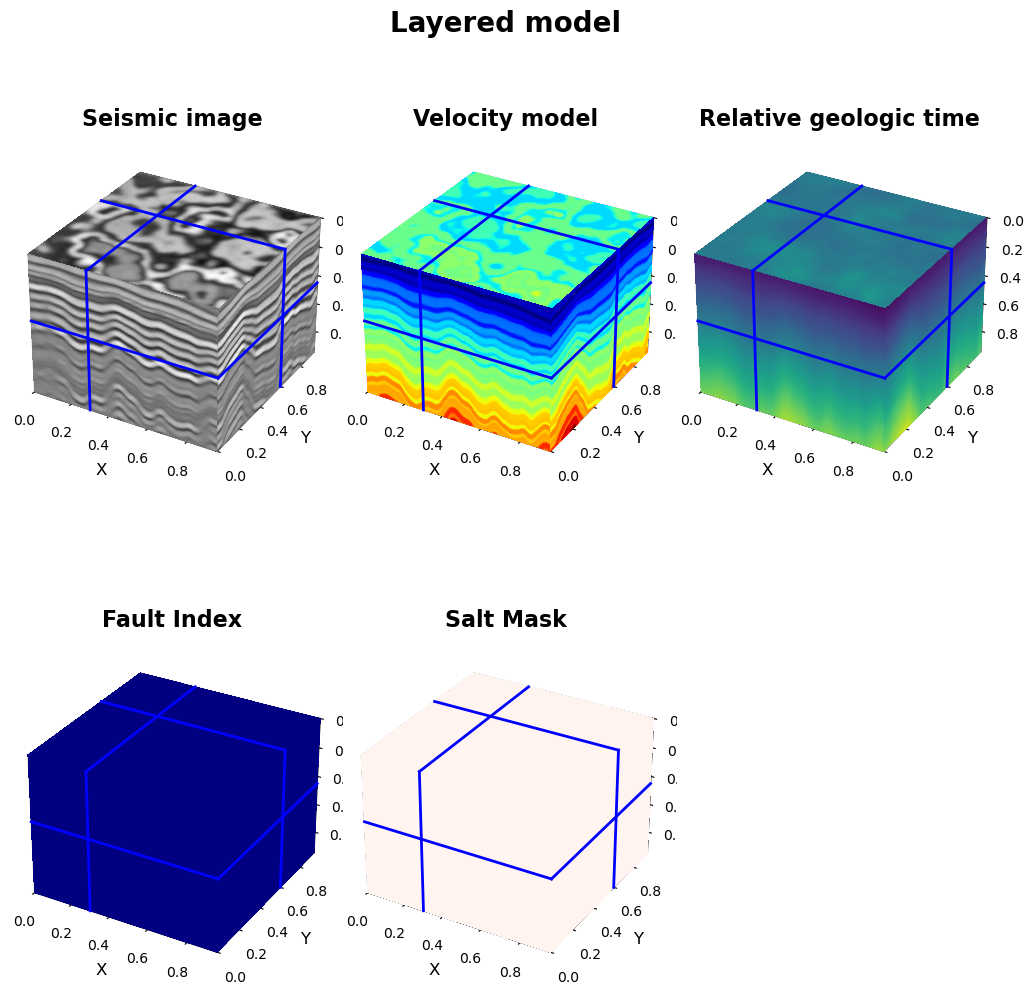

In [47]:
plot_all_models(
    data_root, 
    model_folders, 
    6526, 
    "Layered model",
)

## Fault model

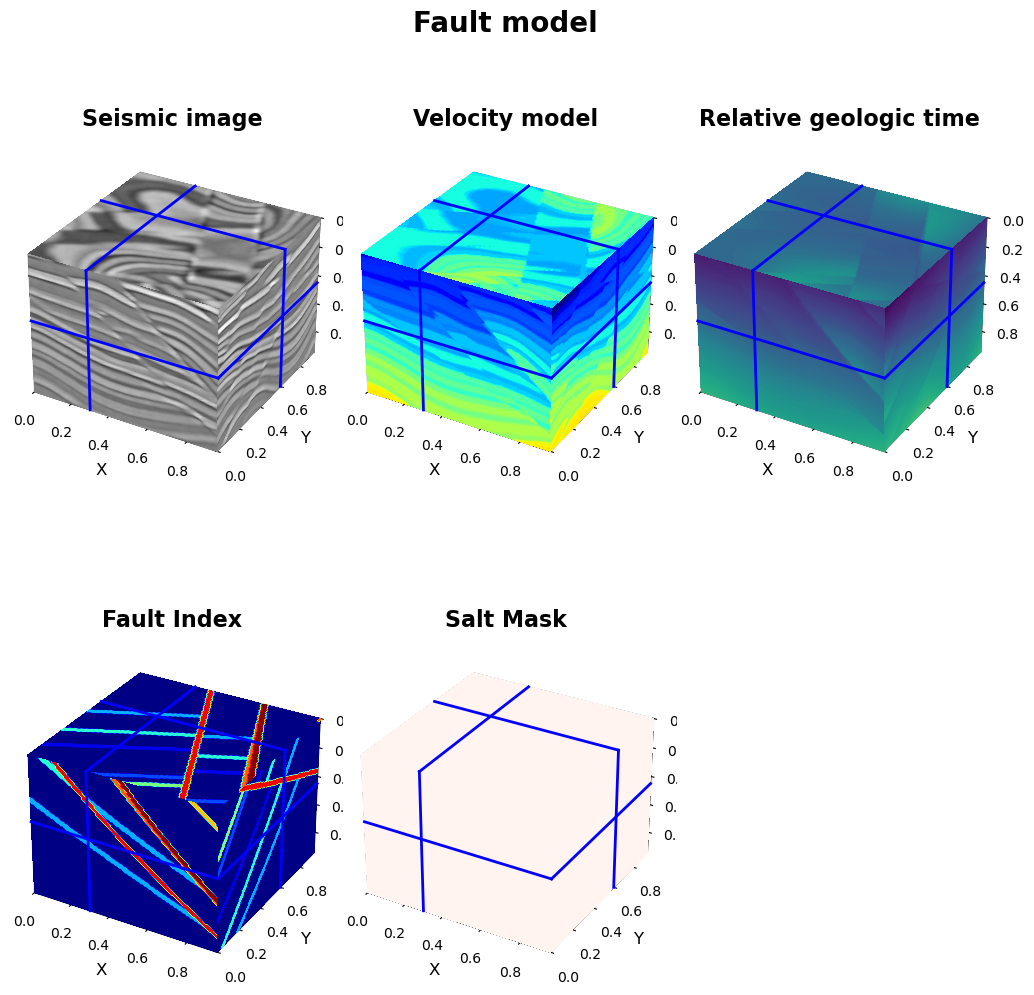

In [ ]:
plot_all_models(    
    data_root, 
    model_folders, 
    3866, 
    "Fault model",
)

## Salt model

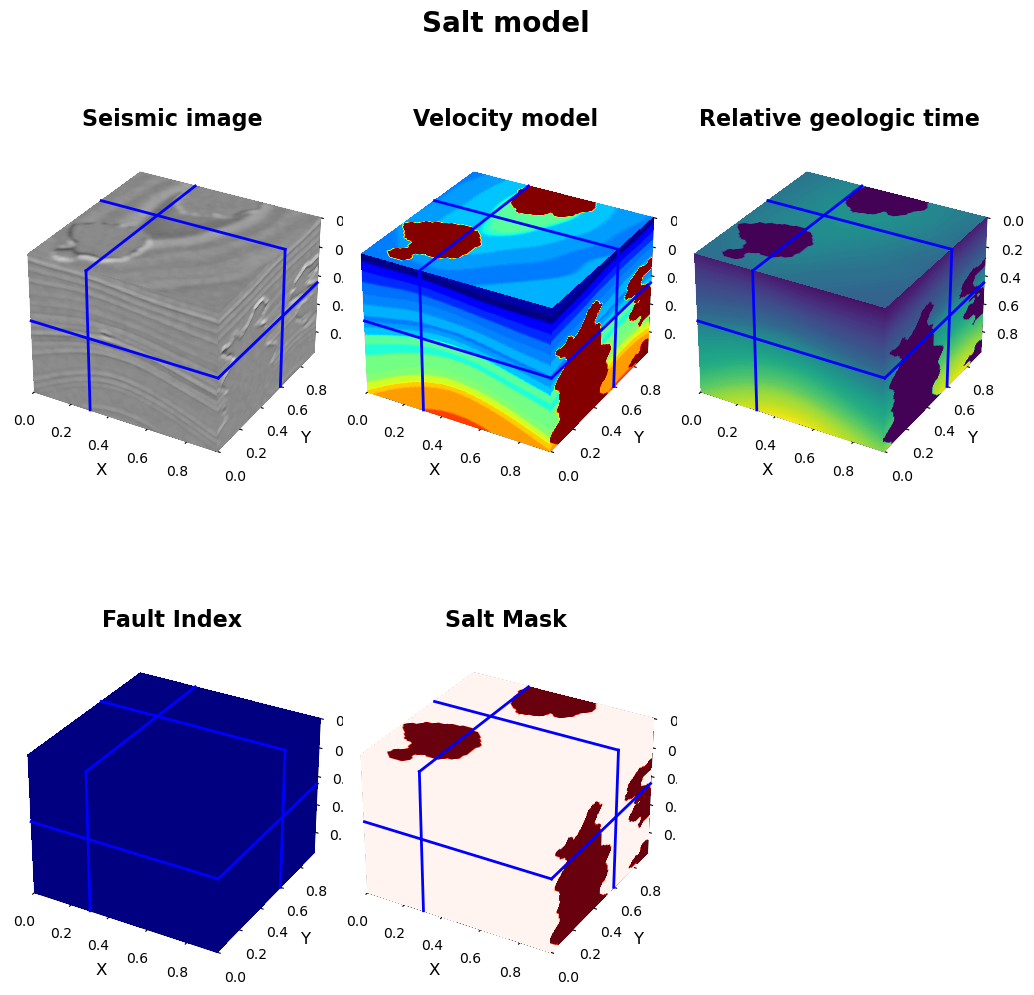

In [ ]:
plot_all_models(
    data_root, 
    model_folders, 
    4831, 
    "Salt model",
)

## Model with salt and faults

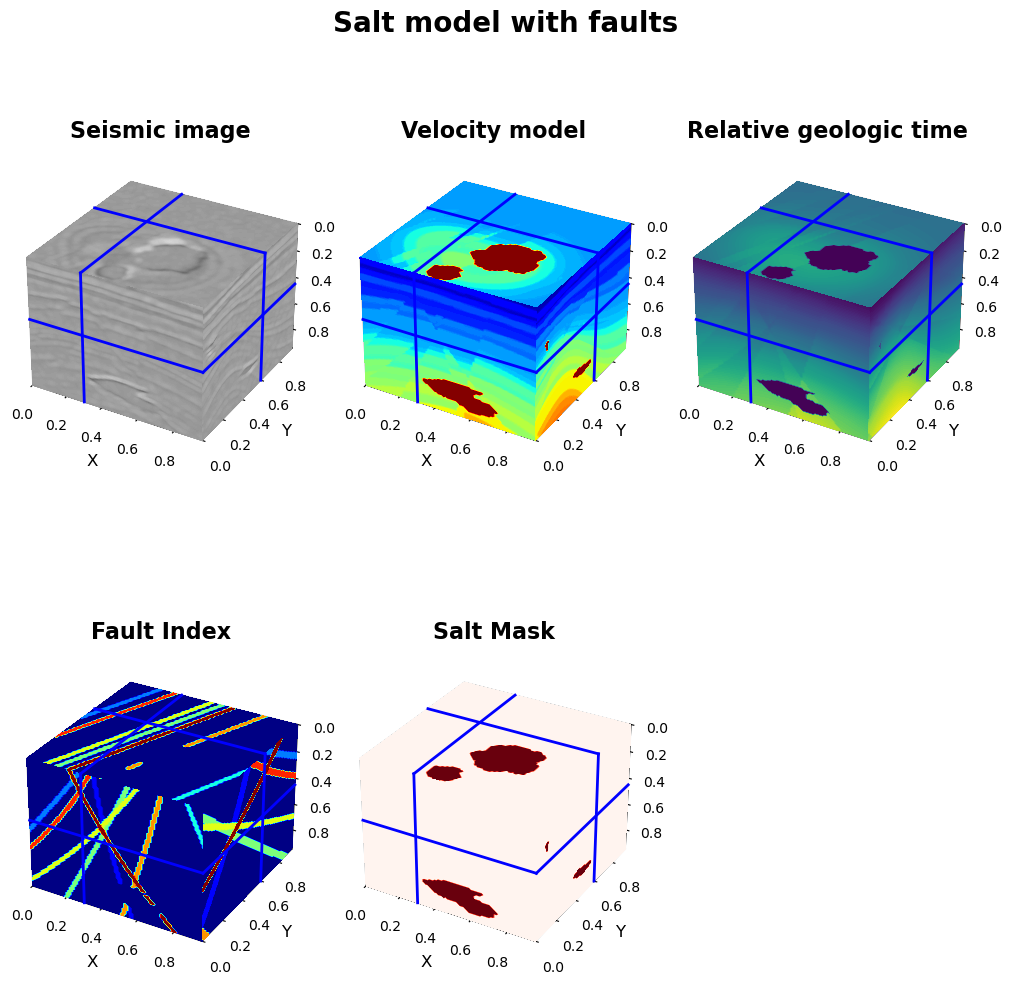

In [57]:
plot_all_models(
    data_root, 
    model_folders, 
    9177, 
    "Salt model with faults",
    save_path="../gallery/salt_fault_model.png"
)

### Fault data

The fault data corresponds to the index of each fault, if you want to plot only `fault == 1`

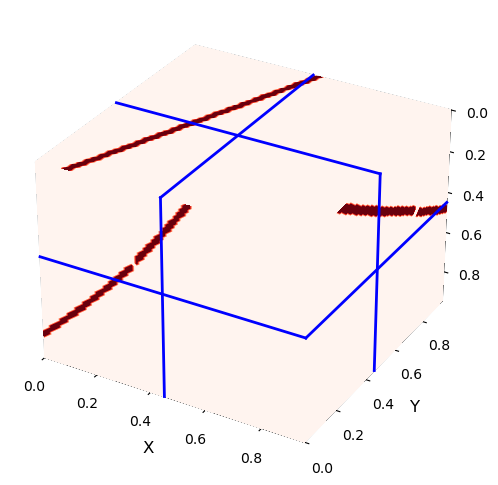

In [53]:
image, vp, rgt, fault, salt = read_models(data_root, model_folders, 9177)
fault_mask = fault.T == 5
plot3d(
    fault_mask.astype(np.float32),
    cmap='Reds',
    frames=[45, 45, 46],
    ifnewfig=True,  
    showf=False,     
    close=False,     
    ifinside=False,
    figname="../gallery/fault_mask_5.png"
)
plt.show()

### Salt bodies can be obtained from the relative geological time data
Salt bodies have rgt value `0`

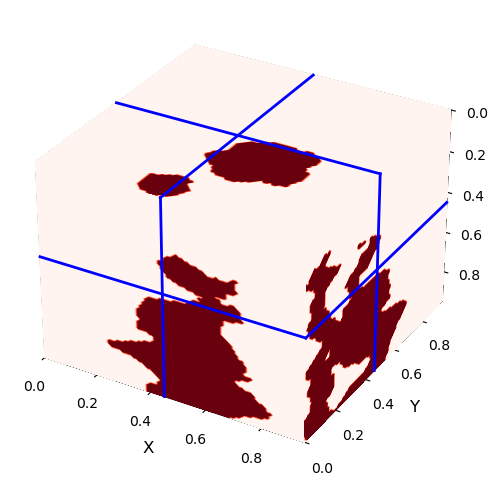

In [54]:
salt_mask = rgt == 0
salt_mask = salt_mask.astype(np.float32)
plot3d(
    salt_mask.T,
    cmap='Reds',
    frames=[45, 45, 46],
    ifnewfig=True,   
    figname="../gallery/salt_mask.png"
)
plt.show()

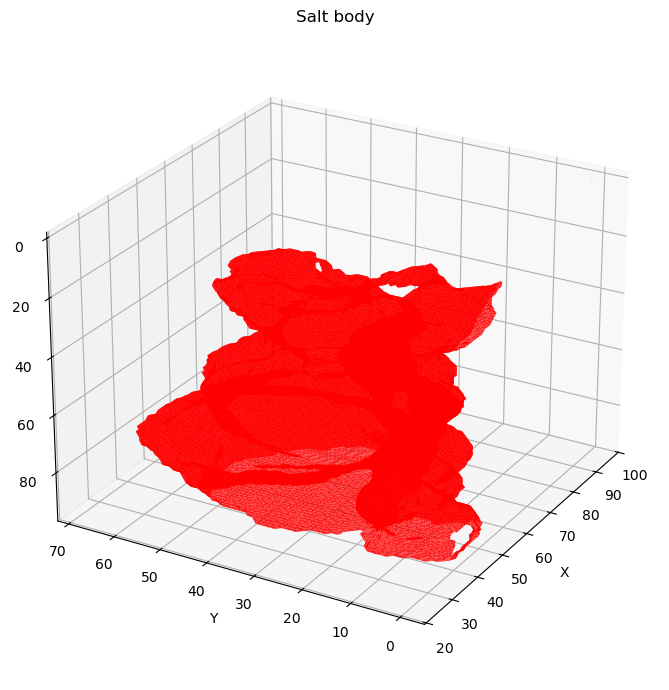

In [45]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

verts, faces, _, _ = marching_cubes(salt_mask.T, level=0.5, spacing=(1.0, 1.0, 1.0))
ax.plot_trisurf(
    verts[:, 1], verts[:, 2], verts[:, 0],
    triangles=faces, color="red", lw=0, antialiased=True, alpha=0.9, shade=False,
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.invert_zaxis()
ax.set_title("Salt body")
ax.view_init(elev=25, azim=-150)
plt.tight_layout()
plt.show()
